In [1]:
# Enable automatic reloading of modified scripts
%load_ext autoreload
%autoreload 2

Total images found: 8325
Selected: C:\Users\ferra\MIC\1r_any_UNICAS\2n_Semestre\Image_Processing_and_Analysis\project\MIC_project\Proposal_StenosisDetection\dataset_subtracted\066\9\14_066_9_0055.png
Bounding boxes found: 2


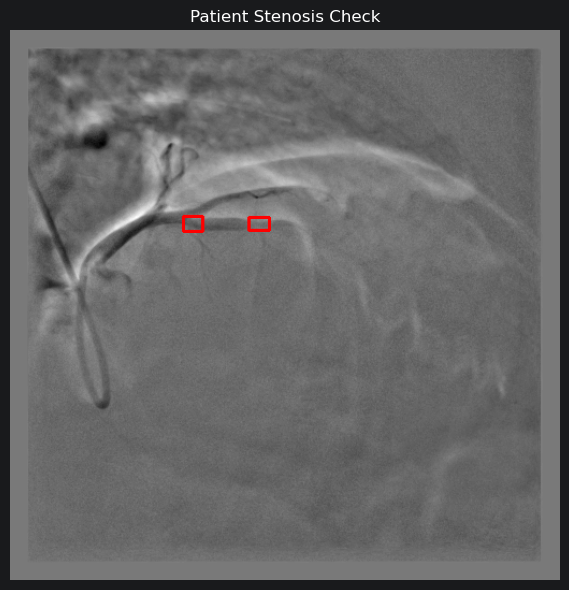

In [2]:
from src.utils import *
import random

paths = get_all_image_paths()
random_path = random.choice(paths)
print(f"Selected: {random_path}")

test_path = r"C:\Users\ferra\MIC\1r_any_UNICAS\2n_Semestre\Image_Processing_and_Analysis\project\MIC_project\Proposal_StenosisDetection\dataset_subtracted\002\5\14_002_5_0017.png"

img   = load_image(test_path)
boxes = parse_stenosis_xml(get_xml_path(test_path))
print(f"Bounding boxes found: {len(boxes)}")

img_annotated = draw_bboxes(img, boxes)
im_show(img_annotated, title="Patient Stenosis Check", figsize=(6, 6))
#im_show(img,title = "Raw image", figsize=(6,6))

## Stenosis ROI Mosaic
Visual survey of all ground-truth stenosis regions across the dataset.
Each tile is one annotated bounding box, resized to the same size for comparison.

In [ ]:
from src.region_visualization import collect_all_rois, build_mosaic, show_mosaic

# Tweak these to your liking
PADDING   = 30    # extra pixels of context around each bounding box
TILE_SIZE = (128, 128)  # (width, height) of each tile in the mosaic
N_COLS    = 6   # number of columns in the grid

In [ ]:
roi_records = collect_all_rois(paths, padding=PADDING)

In [ ]:
rois   = [r['roi'] for r in roi_records]
mosaic = build_mosaic(rois, tile_size=TILE_SIZE, n_cols=N_COLS)
show_mosaic(mosaic, title=f"Stenosis ROI Mosaic  ({len(rois)} regions)")

# Description of Bounding boxes of ground truth:

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Collect every bounding box across the full dataset ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
import numpy as np
from collections import defaultdict

bbox_records = []        # one dict per box
box_counts   = defaultdict(int)

for path in paths:
    boxes = parse_stenosis_xml(get_xml_path(path))
    if not boxes:
        continue
    box_counts[path] = len(boxes)
    for box in boxes:
        w = box['xmax'] - box['xmin']
        h = box['ymax'] - box['ymin']
        bbox_records.append({
            'path'  : path,
            'box'   : box,
            'w'     : w,
            'h'     : h,
            'area'  : w * h,
            'aspect': w / h if h > 0 else float('nan'),
        })

areas   = np.array([r['area']   for r in bbox_records])
widths  = np.array([r['w']      for r in bbox_records])
heights = np.array([r['h']      for r in bbox_records])
aspects = np.array([r['aspect'] for r in bbox_records])

n_annotated = len(box_counts)
n_multi     = sum(1 for c in box_counts.values() if c > 1)

print(f"Total bounding boxes : {len(bbox_records)}")
print(f"Annotated images     : {n_annotated}")
print(f"Images with >1 bbox  : {n_multi}")

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Summary statistics table ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
import pandas as pd

def _describe(arr, label):
    return {
        'Metric' : label,
        'Mean'   : np.mean(arr),
        'Median' : np.median(arr),
        'Std'    : np.std(arr),
        'Min'    : np.min(arr),
        'Max'    : np.max(arr),
        'P25'    : np.percentile(arr, 25),
        'P75'    : np.percentile(arr, 75),
    }

stats_df = pd.DataFrame([
    _describe(areas,              'Area (px﷿﷿)'),
    _describe(widths,             'Width (px)'),
    _describe(heights,            'Height (px)'),
    _describe(np.sqrt(areas),     'Side (﷿﷿﷿area, px)'),
    _describe(aspects,            'Aspect ratio (W/H)'),
]).set_index('Metric').round(2)

display(stats_df)

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Extreme bounding boxes ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
from pathlib import Path

extremes = {
    'Smallest area'  : bbox_records[np.argmin(areas)],
    'Largest area'   : bbox_records[np.argmax(areas)],
    'Smallest width' : bbox_records[np.argmin(widths)],
    'Largest width'  : bbox_records[np.argmax(widths)],
    'Smallest height': bbox_records[np.argmin(heights)],
    'Largest height' : bbox_records[np.argmax(heights)],
}

rows = []
for label, r in extremes.items():
    rows.append({
        'Case'      : label,
        'W (px)'    : r['w'],
        'H (px)'    : r['h'],
        'Area (px﷿﷿)': r['area'],
        'W/H'       : round(r['aspect'], 3),
        'File'      : Path(r['path']).name,
        'Patient'   : Path(r['path']).parts[-3],
        'Serie'     : Path(r['path']).parts[-2],
    })

display(pd.DataFrame(rows).set_index('Case'))

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Distribution plots: area, width, height, aspect ratio ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Bounding Box Distributions', fontsize=14, fontweight='bold')

plot_cfg = [
    (axes[0, 0], areas,   'Area (px﷿﷿)',          'steelblue'),
    (axes[0, 1], widths,  'Width (px)',           'mediumseagreen'),
    (axes[1, 0], heights, 'Height (px)',          'mediumpurple'),
    (axes[1, 1], aspects, 'Aspect ratio (W / H)', 'darkorange'),
]

for ax, data, xlabel, color in plot_cfg:
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4)
    mean_val = np.nanmean(data)
    ax.axvline(mean_val, color='tomato', linestyle='--', linewidth=1.4,
               label=f'mean = {mean_val:.1f}')
    if xlabel == 'Aspect ratio (W / H)':
        ax.axvline(1.0, color='gray', linestyle=':', linewidth=1, label='square (1:1)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_title(xlabel)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Width vs Height scatter (colour = area) ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(widths, heights, c=areas, cmap='viridis',
                alpha=0.6, s=18, linewidths=0)
plt.colorbar(sc, ax=ax, label='Area (px﷿﷿)')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.set_title('Width vs Height  (colour = Area)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Boxes-per-image histogram ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
count_vals = list(box_counts.values())
max_count  = max(count_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(count_vals, bins=range(1, max_count + 2), align='left',
        color='steelblue', edgecolor='white', rwidth=0.7)
ax.set_xlabel('Bounding boxes per image')
ax.set_ylabel('Number of images')
ax.set_title('Boxes-per-image distribution')
ax.set_xticks(range(1, max_count + 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nImages with exactly 1 box : {count_vals.count(1)}")
for k in range(2, max_count + 1):
    print(f"Images with exactly {k} boxes: {count_vals.count(k)}")

### Images with multiple bounding boxes
Each image below has more than one annotated stenosis region. Boxes are colour-coded and labelled with their dimensions.

In [ ]:
# ﷿﷿﷿﷿﷿﷿ Visualise all multi-bbox images ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
import matplotlib.patches as patches

BBOX_COLORS = ['#FF4136', '#2ECC40', '#0074D9', '#FF851B', '#B10DC9']

multi_items = [(p, c) for p, c in box_counts.items() if c > 1]

if not multi_items:
    print("No images with multiple bounding boxes found.")
else:
    n    = len(multi_items)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for i, (path, _) in enumerate(multi_items):
        img   = load_image(path)
        boxes = parse_stenosis_xml(get_xml_path(path))
        ax    = axes_flat[i]

        if img is not None:
            ax.imshow(img, cmap='gray')
            for j, box in enumerate(boxes):
                color = BBOX_COLORS[j % len(BBOX_COLORS)]
                w = box['xmax'] - box['xmin']
                h = box['ymax'] - box['ymin']
                ax.add_patch(patches.Rectangle(
                    (box['xmin'], box['ymin']), w, h,
                    linewidth=2, edgecolor=color, facecolor='none'
                ))
                ax.text(box['xmin'], box['ymin'] - 5,
                        f"#{j+1}  {w}﷿﷿{h}px",
                        color=color, fontsize=7, fontweight='bold')

        parts = Path(path).parts
        ax.set_title(f"{parts[-3]}/{parts[-2]}\n{Path(path).name}\n({len(boxes)} boxes)",
                     fontsize=7)
        ax.axis('off')

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    fig.suptitle(f"Images with multiple bounding boxes  (n={n})",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()